# Stationary State of the Heat Equation in 2D

In this section, we want to find the stationary temperature distribution in a 2D square with the
following boundary conditions:

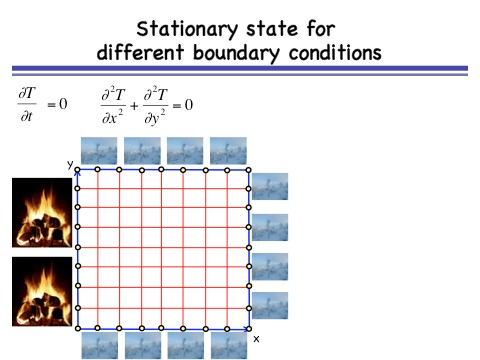

Imagine you are renting a room of size L×L that has three cold outside walls and one wall that is
heated by your neighbor. The outside temperature is kept fixed at 0°C and inside wall at 100°C.
Divide the square into N×N segments. N=51 is a good resolution to start. Solving this problem
numerically requires a 2D array Ti,j or in Python language an array T[i,j].
Convert the analytic form of the 2D heat equation given in the lecture slide above into the
discretized form using Ti,j. Derive the 2D version of equation (*) given above.

$(T_{i,j})^{new} =\quad...\quad[...\quad...\quad...\quad...]$

(1) Write a code to set the boundary value of the 2D array T(i,j) .

(2) Similar to part 1 introduce a main, outer loop over iterations.

(3) Inside the main loop, introduce a nested pair of inner loops over i and j that cover all interior
points of the square above. At each point, you should set the value of Tnew(i,j) according to
equation (**).

(4) As in part 1, copy the data back and forth between T and Tnew.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

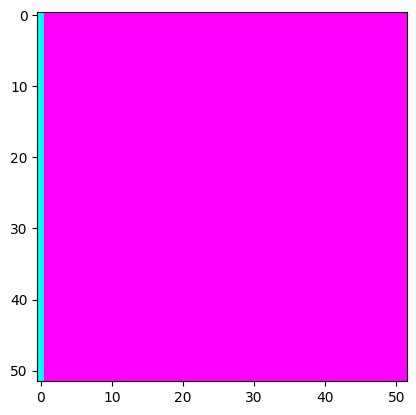

In [ ]:
N=51 # Tentukan jumlah segmen grid -> 51x51
T = np.zeros((N+1, N+1)) # array 2d ukuran 52x52 (dari 0 s/d 51) semuanya 0
T[:,0] = 1 # boundary condition, semua baris di kolom 0 diisi 1 (100°C dlm skala simulasi ini)

plt.imshow(T, cmap='cool_r')
plt.show()

range(0, 52)
283.57358967549544


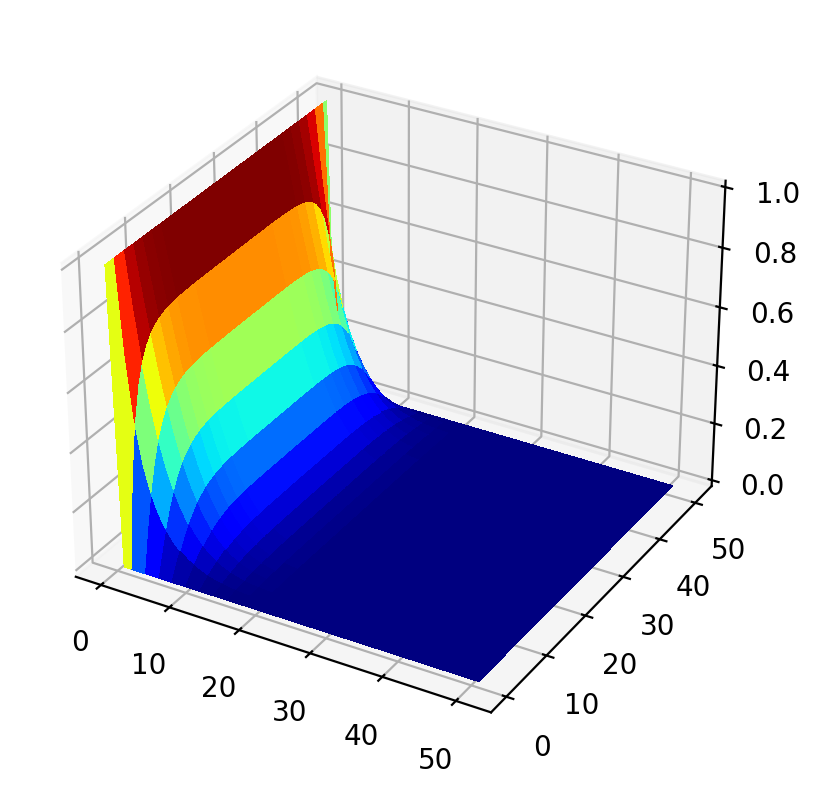

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

N = 51 # Tentukan jumlah segmen grid -> 51x51
T = np.zeros((N+1, N+1)) # array 2d ukuran 52x52 (dari 0 s/d 51) semuanya 0
T[:,0] = 1 # boundary condition, semua baris di kolom 0 diisi 1 (100°C dlm skala simulasi ini)

X = range(N+1) # urutan integer dr 0 s/d 51 (indeks/titik2 di sumbu horizontal)
Y = range(N+1) # urutan integer dr 0 s/d 51 (indeks/titik2 di sumbu vertikal)
X,Y = np.meshgrid(X,Y) # Membuat koordinat grid (2D array) untuk sumbu X dan Y
fig = plt.figure(dpi=200)
for k in range(100): # loop utama: 100 iterasi
  newT = np.copy(T) # simpan nilai T di newT
  for i in range(1,N): # inner loop 1: dari 1 s/d 50
    for j in range(1,N): # inner loop 2: dari 1 s/d 50
      # (Suhu di satu titik adalah rata2 dari 4 titik tetangganya -> atas, bawah, kiri, kanan)
      newT[i,j] = .25*(T[i-1,j] + T[i+1,j] + T[i,j-1] + T[i,j+1])
  # Perbarui T dengan nilai newT yang baru saja di update
  T = np.copy(newT)
print(np.sum(newT))
fig.clear()
# Visualisasi dalam bentuk 3D
ax = fig.add_subplot(projection='3d')
# X dan Y adalah pondasi (alas), sedangkan newT adalah ketinggiannya (dimensi ketiga)
ax.plot_surface(X, Y, newT, cmap='jet', antialiased=False)
plt.show()

In [ ]:
# Demo untuk melihat isi X dan Y setelah meshgrid

# Setelah perintah X, Y = np.meshgrid(X, Y), variabel X akan menjadi array 2D di mana
# baris [0, 1, 2, ..., 51] diulang sebanyak 52 kali (dari indeks 0 sampai 51) ke bawah.
print(f"Bentuk array X: {X.shape}")
print("Isi beberapa baris pertama array X:")
print(X[:3, :10]) # Mencetak 3 baris pertama dan 10 kolom pertama

# Sebaliknya, Y akan berisi kolom [0, 1, 2, ..., 51] yang diulang sebanyak 52 kali ke samping.
print(f"\nBentuk array Y: {Y.shape}")
print("Isi beberapa baris pertama array Y:")
print(Y[:3, :10])

# Maka, setiap pasangan (X[i,j], Y[i,j]) mendefinisikan koordinat unik di atas 'lantai' grid kita.

Bentuk array X: (52, 52)
Isi beberapa baris pertama array X:
[[0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]]

Bentuk array Y: (52, 52)
Isi beberapa baris pertama array Y:
[[0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1]
 [2 2 2 2 2 2 2 2 2 2]]


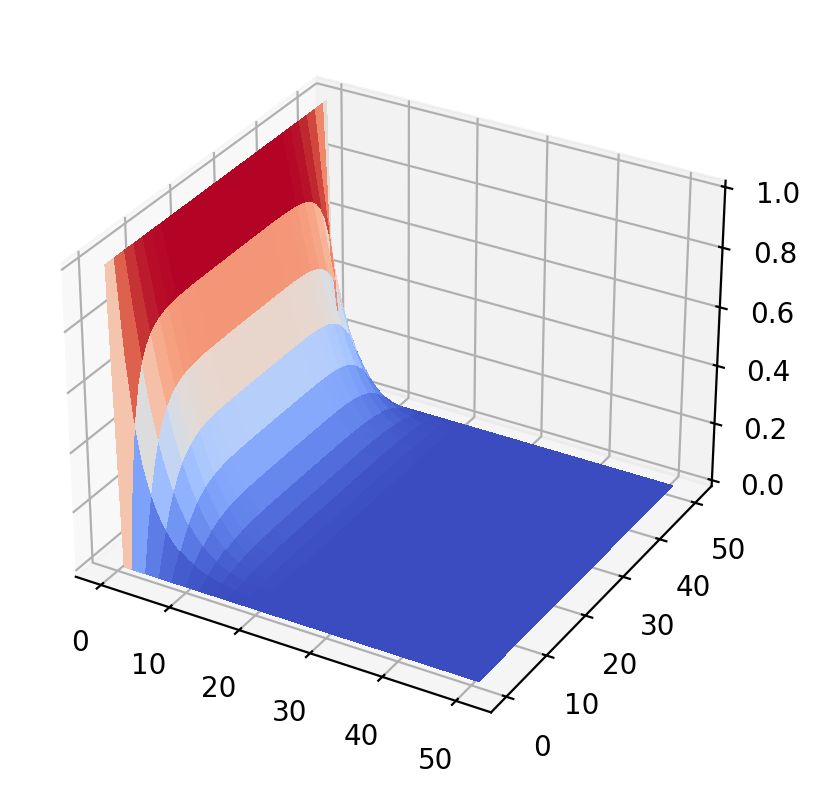

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.animation import FFMpegWriter

N = 51
T = np.zeros((N+1, N+1))
T[:,0] = 1

X = range(N+1)
Y = range(N+1)
X,Y = np.meshgrid(X,Y)

metadata = dict(title='My first animation in 3D', artist='Matplotlib', comment='Wakanda is here now.')
writer = FFMpegWriter(fps=15, metadata=metadata, bitrate=200000)
fig = plt.figure(dpi=200)

with writer.saving(fig, "wave2d.mp4", dpi=200):
  for k in range(100):
    newT = np.copy(T)
    for i in range(1,N):
      for j in range(1,N):
        newT[i,j] = .25*(T[i-1,j] + T[i+1,j] + T[i,j-1] + T[i,j+1])
    T = np.copy(newT)
    fig.clear()
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(X, Y, T, cmap=cm.coolwarm, antialiased=False)
    writer.grab_frame()

### Animation Result

Here's the generated 3D animation:

In [ ]:
from IPython.display import Video

Video("wave2d.mp4", embed=True)

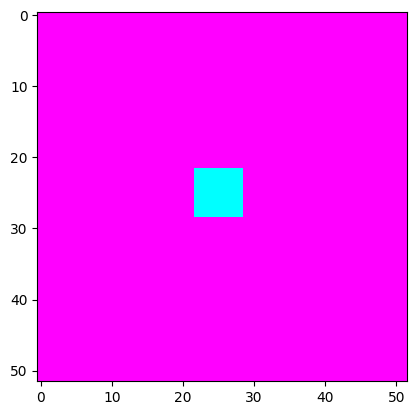

In [ ]:
N=51
T = np.zeros((N+1, N+1))
T[22:29, 22:29] = 1

plt.imshow(T, cmap='cool_r')
plt.show()

48.900513155931804


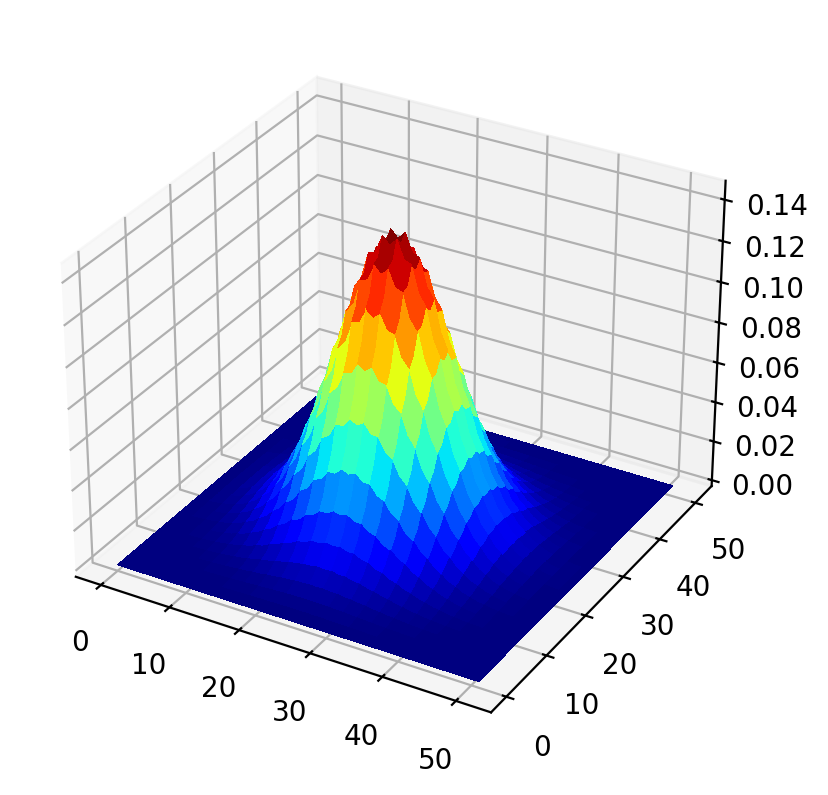

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

N = 51
T = np.zeros((N+1, N+1))
T[22:29, 22:29] = 1 # 22, 23, 24, 25, 26, 27, and 28.

X = range(N+1)
Y = range(N+1)
X,Y = np.meshgrid(X,Y)
fig = plt.figure(dpi=200)
for k in range(100):
  newT = np.copy(T)
  for i in range(1,N):
    for j in range(1,N):
      newT[i,j] = .25*(T[i-1,j] + T[i+1,j] + T[i,j-1] + T[i,j+1])
  T = np.copy(newT)
print(np.sum(newT))
fig.clear()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, newT, cmap='jet', antialiased=False)
plt.show()

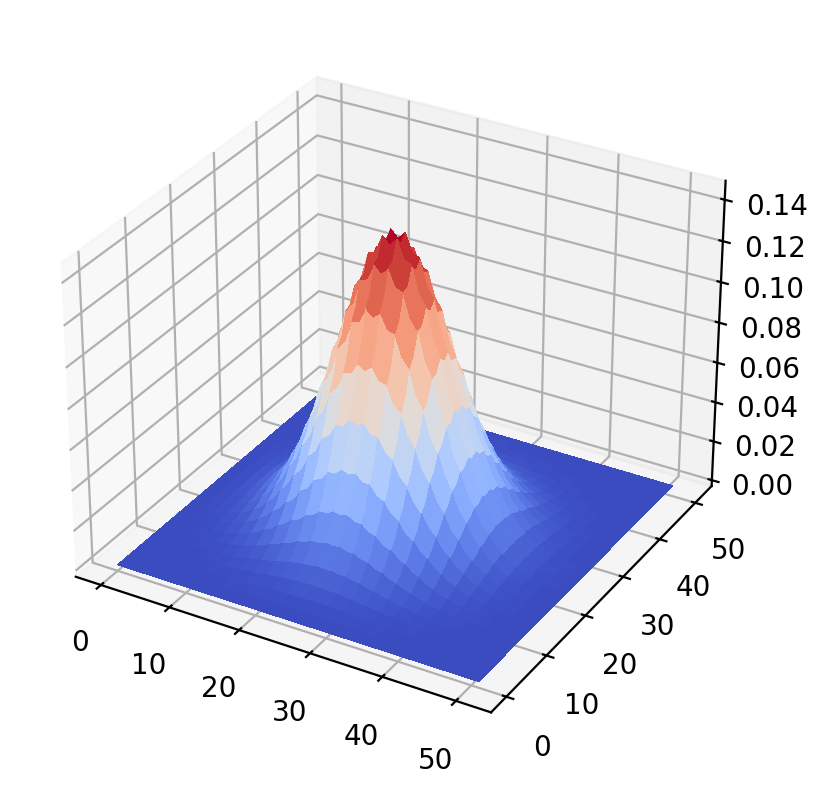

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.animation import FFMpegWriter

N = 51
T = np.zeros((N+1, N+1))
T[22:29, 22:29] = 1

X = range(N+1)
Y = range(N+1)
X,Y = np.meshgrid(X,Y)

metadata = dict(title='My first animation in 3D', artist='Matplotlib', comment='Wakanda is here now.')
writer = FFMpegWriter(fps=15, metadata=metadata, bitrate=200000)
fig = plt.figure(dpi=200)

with writer.saving(fig, "wave2d.mp4", dpi=200):
  for k in range(100):
    newT = np.copy(T)
    for i in range(1,N):
      for j in range(1,N):
        newT[i,j] = .25*(T[i-1,j] + T[i+1,j] + T[i,j-1] + T[i,j+1])
    T = np.copy(newT)
    fig.clear()
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(X, Y, T, cmap=cm.coolwarm, antialiased=False)
    writer.grab_frame()

In [ ]:
from IPython.display import Video

Video("wave2d.mp4", embed=True)

Output hidden; open in https://colab.research.google.com to view.

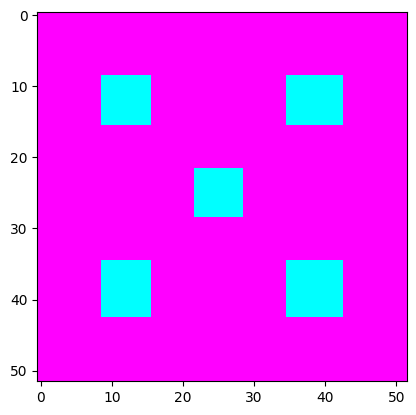

In [ ]:
N=51
T = np.zeros((N+1, N+1))
T[22:29, 22:29] = 100
T[35:43, 35:43] = 100
T[9:16, 9:16] = 100
T[9:16,35:43] = 100
T[35:43, 9:16] = 100

plt.imshow(T, cmap='cool_r')
plt.show()

23199.614709659603


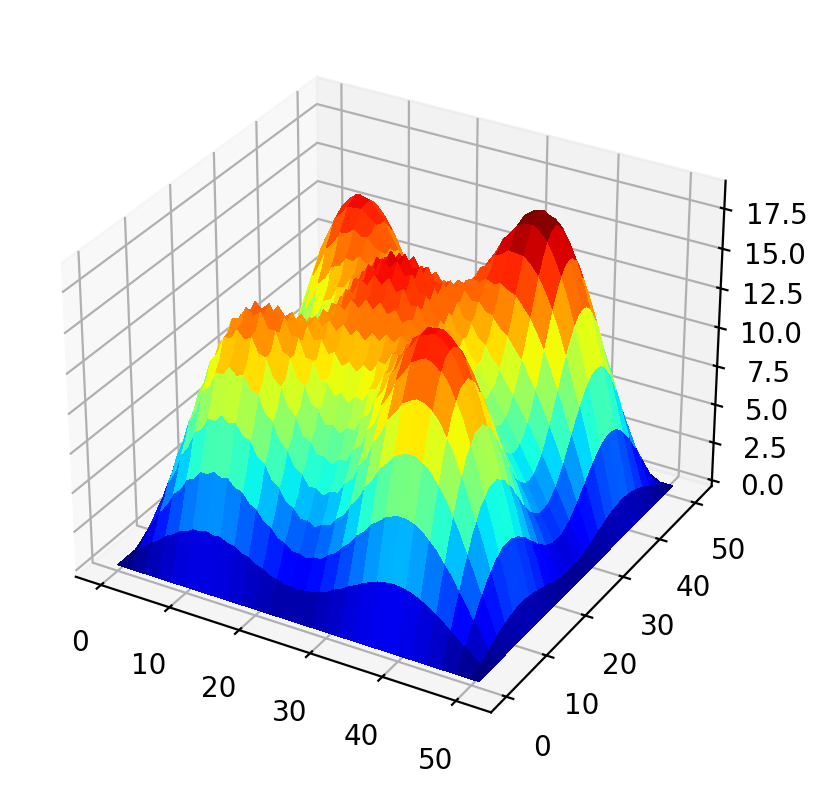

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

N = 51
T = np.zeros((N+1, N+1))
T[22:29, 22:29] = 100
T[35:43, 35:43] = 100
T[9:16, 9:16] = 100
T[9:16,35:43] = 100
T[35:43, 9:16] = 100

X = range(N+1)
Y = range(N+1)
X,Y = np.meshgrid(X,Y)
fig = plt.figure(dpi=200)
for k in range(100):
  newT = np.copy(T)
  for i in range(1,N):
    for j in range(1,N):
      newT[i,j] = .25*(T[i-1,j] + T[i+1,j] + T[i,j-1] + T[i,j+1])
  T = np.copy(newT)
print(np.sum(newT))
fig.clear()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, newT, cmap='jet', antialiased=False)
plt.show()

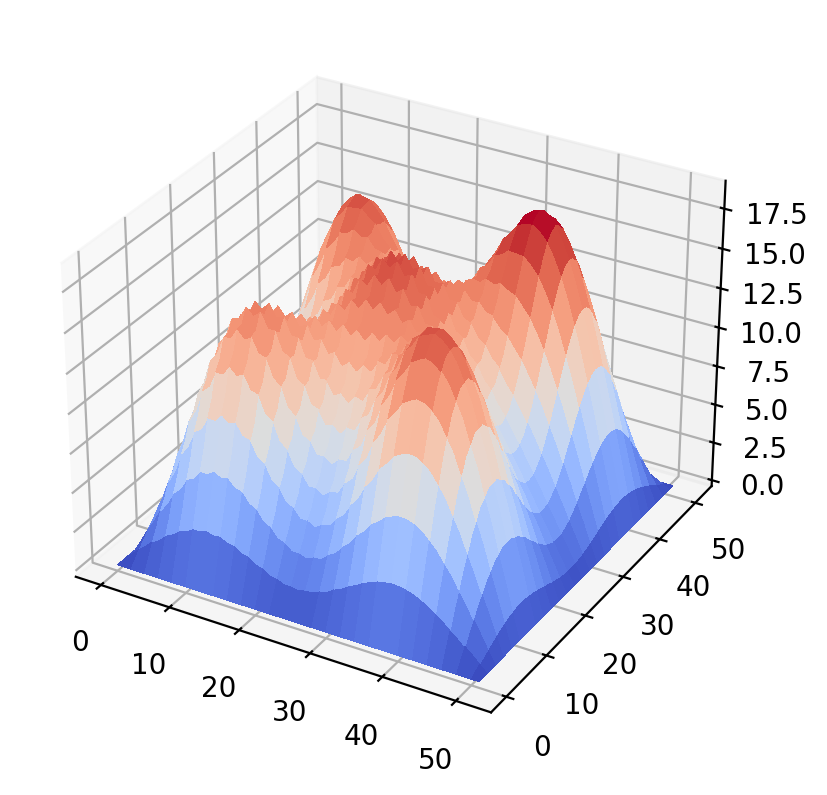

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.animation import FFMpegWriter

N = 51
T = np.zeros((N+1, N+1))
T[22:29, 22:29] = 100
T[35:43, 35:43] = 100
T[9:16, 9:16] = 100
T[9:16,35:43] = 100
T[35:43, 9:16] = 100

X = range(N+1)
Y = range(N+1)
X,Y = np.meshgrid(X,Y)

metadata = dict(title='My first animation in 3D', artist='Matplotlib', comment='Wakanda is here now.')
writer = FFMpegWriter(fps=15, metadata=metadata, bitrate=200000)
fig = plt.figure(dpi=200)

with writer.saving(fig, "wave2d.mp4", dpi=200):
  for k in range(100):
    newT = np.copy(T)
    for i in range(1,N):
      for j in range(1,N):
        newT[i,j] = .25*(T[i-1,j] + T[i+1,j] + T[i,j-1] + T[i,j+1])
    T = np.copy(newT)
    fig.clear()
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(X, Y, T, cmap=cm.coolwarm, antialiased=False)
    writer.grab_frame()

In [ ]:
from IPython.display import Video

Video("wave2d.mp4", embed=True)

Output hidden; open in https://colab.research.google.com to view.